# Empirical--Mock Comparison
Benjamin Floyd

Visually compares multiple properties between the empirical catalog and mock catalogs.

In [1]:
from astropy.table import Table, vstack, hstack
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Read in the empirical catalog
empirical = Table.read('Data_Repository/Project_Data/SPT-IRAGN/Output/SPTcl_IRAGN_no-stars.fits')

In [3]:
# Read in a mock catalog
mock_e4z_1 = Table.read('Data_Repository/Project_Data/SPT-IRAGN/MCMC/Mock_Catalog/Catalogs/local_backgrounds/eta-zeta_slopes/targeted_snr/mock_AGN_catalog_t0.0053_e4.00_z-1.00_b1.00_rc0.100_C0.181_maxr5.00_seed3775_308x1.0_tez_grid.fits')

In [4]:
# For both catalogs make final selections to keep only AGN
empirical = empirical[empirical['SELECTION_MEMBERSHIP'] >= 0.5]
mock_e4z_1 = mock_e4z_1[mock_e4z_1['SELECTION_MEMBERSHIP'] >= 0.5]

# For the mock, also impose the photometric incompleteness
mock_e4z_1 = mock_e4z_1[mock_e4z_1['COMPLETENESS_REJECT'].astype(bool)]

In [5]:
# Group and aggregate based on cluster/LoS
empirical_grp = empirical.group_by('SPT_ID')
mock_grp = mock_e4z_1.group_by('SPT_ID')

empirical_los = vstack([Table(los[0]) for los in empirical_grp.groups])
mock_los = vstack([Table(los[0]) for los in mock_grp.groups])

empirical_los['RICHNESS'] = empirical_grp['COMPLETENESS_CORRECTION'].groups.aggregate(np.sum)
mock_los['RICHNESS'] = mock_grp['COMPLETENESS_CORRECTION'].groups.aggregate(np.sum)

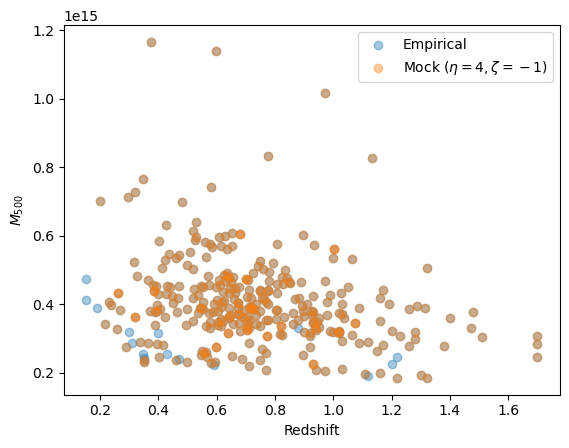

In [6]:
fig, ax = plt.subplots()
ax.scatter(empirical_los['REDSHIFT'], empirical_los['M500'], alpha=0.4, label='Empirical')
ax.scatter(mock_los['REDSHIFT'], mock_los['M500'], alpha=0.4, label=r'Mock ($\eta = 4, \zeta = -1$)')
ax.legend()
ax.set(xlabel='Redshift', ylabel=r'$M_{500}$')
fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/empirical-mock_m500-z.pdf')

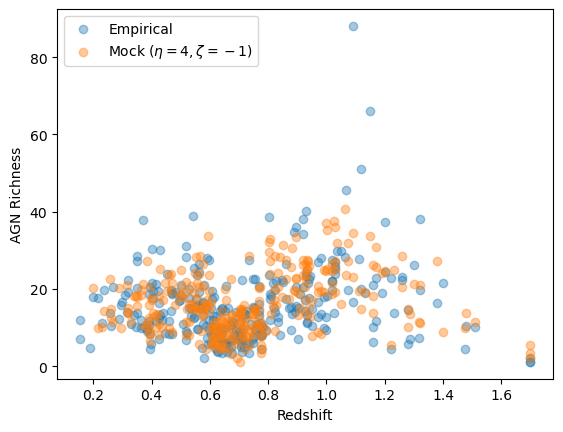

In [7]:
z_bins = np.arange(0., 1.8, 0.1)
fig, ax = plt.subplots()
ax.scatter(empirical_los['REDSHIFT'], empirical_los['RICHNESS'], alpha=0.4, label='Empirical')
ax.scatter(mock_los['REDSHIFT'], mock_los['RICHNESS'], alpha=0.4, label=r'Mock ($\eta = 4, \zeta = -1$)')
ax.legend()
ax.set(xlabel='Redshift', ylabel='AGN Richness')
fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/empirical-mock_richness-z.pdf')

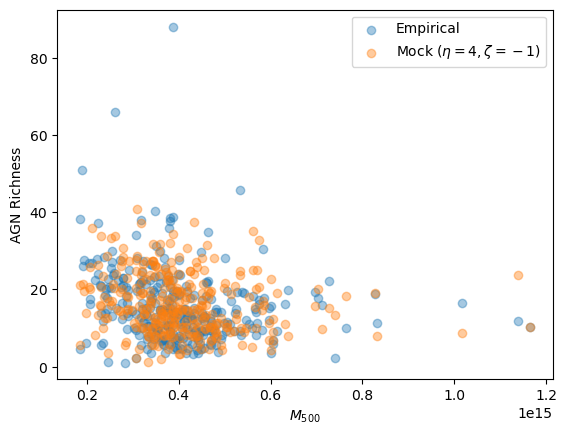

In [8]:
m_bins = np.arange(1e14, 1e15, 0.1e14)
fig, ax = plt.subplots()
ax.scatter(empirical_los['M500'], empirical_los['RICHNESS'], alpha=0.4, label='Empirical')
ax.scatter(mock_los['M500'], mock_los['RICHNESS'], alpha=0.4, label=r'Mock ($\eta = 4, \zeta = -1$)')
ax.legend()
ax.set(xlabel=r'$M_{500}$', ylabel='AGN Richness')
fig.savefig('Data_Repository/Project_Data/SPT-IRAGN/Misc_Plots/empirical-mock_richness-m500.pdf')